In [1]:
import pickle
import numpy as np
import sympy as sp
import pandas as pd
from time import time
from IPython.display import display
import matplotlib.pyplot as plt

In [2]:
from sklearn.metrics import mean_squared_error

def eval_equations(x, y, equations):
    """
    Evalúa una lista de expresiones matemáticas contra los datos y calcula el MSE para cada una.

    :param x: dataframe con las variables
    :param y: variable objetivo
    :param equations: dataframe/lista con las expresiones obtenidas
    :return: lista de tuplas (expresión, MSE) ordenadas de menor a mayor MSE.
    """
    resultados = []

    for eq in equations:
        try:
            float(eq)
            resultados.append(np.inf)
        except ValueError:
            y_pred = eval(eq, {"__builtins__": {}, "np": np, 'log': np.log, 'exp': np.exp}, x.to_dict(orient='series'))
            mse = mean_squared_error(y, y_pred)
            resultados.append(mse)

    return pd.DataFrame({'expresiones': equations, 'mse': resultados})

def get_general_metrics(y_pred, y_true):
    """
    Calcula las métricas de error RMSE, MAE y SMAPE, junto con su desviación estándar.
    :param y_pred: Arreglo con los valores predichos por la ecuación obtenida.
    :param y_true: Arreglo con los valores reales de la variable.
    :return: Retorna un diccionario, donde los values son una tupla con el valor de la métrica
             y la desviación estándar; y las keys son los strings de las métricas calculadas
             i.e. 'RMSE', 'MAE, 'SMAPE'.
    """

    # Cálculo de errores
    errores_rmse = (y_true - y_pred) ** 2
    errores_mae = np.abs(y_true - y_pred)
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2 + 1e-6
    errores_smape = (np.abs(y_true - y_pred) / denominator) * 100

    # Cálculo de métricas
    rmse = np.round(np.sqrt(np.mean(errores_rmse)), 2)
    mae = np.round(np.mean(errores_mae), 2)
    smape = np.round(np.mean(errores_smape), 2)

    # Cálculo de desviaciones estándar
    std_rmse = np.round(np.std(np.sqrt(errores_rmse)), 2)
    std_mae = np.round(np.std(errores_mae), 2)
    std_smape = np.round(np.std(errores_smape), 2)

    # Retorna un diccionario con las métricas y sus desviaciones estándar
    return {
        "RMSE": (float(rmse), float(std_rmse)),
        "MAE": (float(mae), float(std_mae)),
        "SMAPE": (float(smape), float(std_smape))
    }

In [2]:
from pysr import PySRRegressor

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


In [3]:
nu_25 = pd.read_csv('nu_25.csv')
x_train = nu_25[['Re', 'S', 'SoH', 'Pr']].rename({'S': 'Se'}, axis=1)
y_train = nu_25['Nu']

In [16]:
nu_53 = pd.read_csv('nu_53.csv')

x_val, y_val, x_test, y_test = [], [], [], []
for soh in nu_53['SoH'].unique():
    df = nu_53[nu_53['SoH'] == soh]

    x_val.append(df.iloc[: len(df) // 2][['Re', 'S', 'SoH', 'Pr']])
    y_val.append(df.iloc[: len(df) // 2]['Nu'])

    x_test.append(df.iloc[len(df) // 2: ][['Re', 'S', 'SoH', 'Pr']])
    y_test.append(df.iloc[len(df) // 2: ]['Nu'])

x_val = pd.concat(x_val).rename({'S': 'Se'}, axis=1)
y_val = pd.concat(y_val)
x_test = pd.concat(x_test).rename({'S': 'Se'}, axis=1)
y_test = pd.concat(y_test)

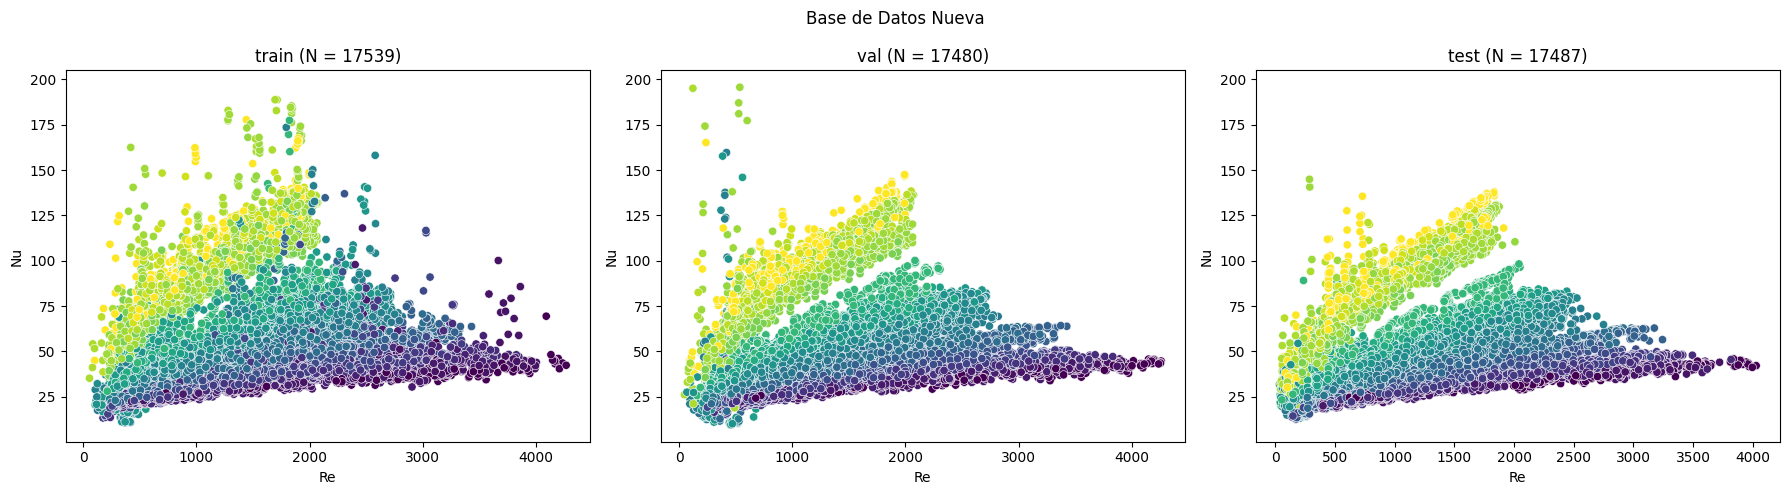

In [17]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

ax[0].scatter(x_train['Re'], y_train, c=x_train['Se'], marker='o', edgecolor='w', linewidth=0.4)
ax[0].set_title(f'train (N = {len(x_train)})')
ax[0].set_xlabel('Re')
ax[0].set_ylabel('Nu')

ax[1].scatter(x_val['Re'], y_val, c=x_val['Se'], marker='o', edgecolor='w', linewidth=0.4)
ax[1].set_title(f'val (N = {len(x_val)})')
ax[1].set_xlabel('Re')
ax[1].set_ylabel('Nu')

ax[2].scatter(x_test['Re'], y_test, c=x_test['Se'], marker='o', edgecolor='w', linewidth=0.4)
ax[2].set_title(f'test (N = {len(x_test)})')
ax[2].set_xlabel('Re')
ax[2].set_ylabel('Nu')

ylims = np.array([ax[i].get_ylim() for i in range(3)])
for i in range(3): ax[i].set_ylim([np.min(ylims[:, 0]), np.max(ylims[:, 1])])

fig.suptitle('Base de Datos Nueva')
plt.tight_layout()
plt.show()

In [6]:
model_batch = PySRRegressor(
    niterations=200,
    binary_operators=["+", "-", "*", "/", "^"],
    unary_operators=[],
    population_size=200,
    populations=2,
    tournament_selection_n=3,
    verbosity=1,
    maxsize=20,
    parsimony=1e-2,
    constraints={'^':(-1,1)},
    complexity_of_variables=1,
    random_state=0,
    progress=False,
    parallelism='serial',
    deterministic=True,
    batching=True,
)

t0 = time()
model_batch.fit(x_train, y_train)
tf = time()

print(f"Tiempo de ejecución: {tf - t0} [s]")

Compiling Julia backend...
[ Info: Started!



Expressions evaluated per second: 7.530e+02
Progress: 14 / 400 total iterations (3.500%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           6.521e+02  0.000e+00  y = 54.598
3           3.395e+02  3.263e-01  y = Se * 22.64
5           2.514e+02  1.502e-01  y = (2.0648 ^ Se) * 8.576
7           2.511e+02  5.109e-04  y = ((2.2663 ^ Se) * 5.8828) - -6.6135
11          2.507e+02  3.886e-04  y = Se * ((Se / 0.12235) - ((SoH * SoH) * -2.4995))
13          2.472e+02  7.177e-03  y = ((((SoH ^ 1.981) + (Se * Se)) / 0.12235) - Se) + -0.50...
                                      395
15          2.258e+02  4.516e-02  y = 1.7994 * (((Se ^ 1.7994) / (0.16854 + ((Se / Re) ^ SoH...
                                      ))) - -1.3183)
17          2.178e+02  1.805e-02  y = 1.7994 * ((((Se ^ 1.7994) / 

[ Info: Final population:
[ Info: Results saved to:


Tiempo de ejecución: 216.29562616348267 [s]


In [60]:
equations = model_batch.equations_['equation']
equations = equations.apply(lambda x: x.replace('^', '**'))
print('=== TRAIN ===')
df_train = eval_equations(x_train, y_train, equations).sort_values(by='mse')
display(df_train)

print('\n=== VALIDATION ===')
df_val = eval_equations(x_val, y_val, equations).sort_values(by='mse')
display(df_val)

=== TRAIN ===


,expresiones,mse
9,((Se + ((Pr * Se) * ((Re * 0.0006306523) * Se)...,71.361604
8,((((((Se - (SoH / Se)) * 2.6339943) / Re) ** -...,75.902977
7,((((((Se - 0.38795748) * 2.6339943) / Re) ** -...,76.960728
6,(((((Se - 0.38795748) * 2.6339943) / Re) ** -0...,79.443990
5,(((Se * (Re ** 0.32908925)) * Se) - 10.22936) ...,82.378095
4,((Se * (Re ** 0.32908925)) * Se) - 10.22936,83.465501
3,(2.1084726 ** Se) * (Re ** 0.2986075),85.782418
2,(2.0647604 ** Se) * 8.638071,251.079507
1,Se / 0.04368084,339.098277
0,53.487057,inf



=== VALIDATION ===


,expresiones,mse
9,((Se + ((Pr * Se) * ((Re * 0.0006306523) * Se)...,51.166786
7,((((((Se - 0.38795748) * 2.6339943) / Re) ** -...,53.100941
8,((((((Se - (SoH / Se)) * 2.6339943) / Re) ** -...,53.624044
5,(((Se * (Re ** 0.32908925)) * Se) - 10.22936) ...,53.655916
4,((Se * (Re ** 0.32908925)) * Se) - 10.22936,54.476545
6,(((((Se - 0.38795748) * 2.6339943) / Re) ** -0...,56.075906
3,(2.1084726 ** Se) * (Re ** 0.2986075),57.549551
2,(2.0647604 ** Se) * 8.638071,216.962815
1,Se / 0.04368084,310.566102
0,53.487057,inf


In [61]:
expr = sp.sympify(
    df_val['expresiones'].iloc[0]
).evalf(4)

Re, Se, SoH, Pr = sp.symbols('Re Se SoH Pr')
f = sp.lambdify((Re, Se, SoH, Pr), expr, 'numpy')

expr

3.106*Se*(0.0006307*Pr*Re*Se**2 + Se) + 9.124*SoH

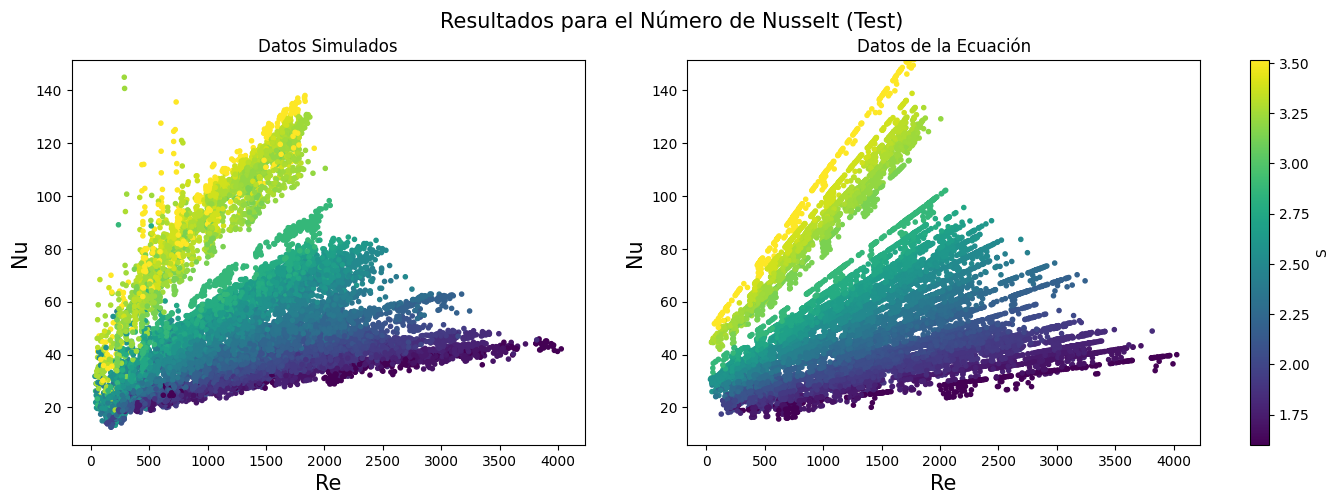

In [130]:
fig, ax = plt.subplots(1, 2, figsize=(16, 5))

x = x_test
y = y_test

sc0 = ax[0].scatter(x['Re'], y, marker='.', c=x['Se'])
ax[0].set_xlabel('Re', fontsize=15)
ax[0].set_ylabel('Nu', fontsize=15)
ax[0].set_title('Datos Simulados')

y_pred = f(x['Re'], x['Se'], x['SoH'], x['Pr'])
sc1 = ax[1].scatter(x['Re'], y_pred, marker='.', c=x['Se'])
ax[1].set_xlabel('Re', fontsize=15)
ax[1].set_ylabel('Nu', fontsize=15)
ax[1].set_ylim(ax[0].get_ylim())
ax[1].set_title('Datos de la Ecuación')

cbar = fig.colorbar(sc1, ax=ax, orientation='vertical', fraction=0.05, pad=0.04)
cbar.set_label('S')

fig.suptitle('Resultados para el Número de Nusselt (Test)', fontsize=15)
plt.show()

## Simulación Daryl

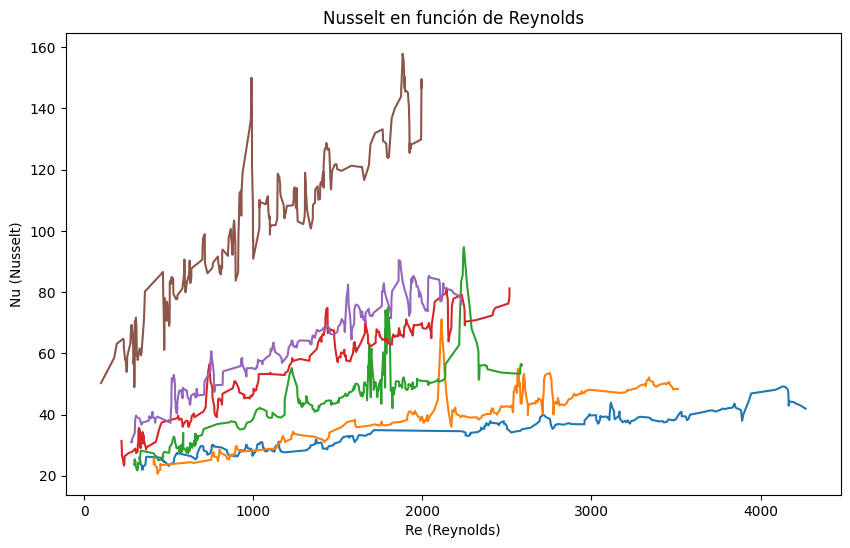

In [197]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import savgol_filter # <--- Importante

x_new0 = x_train.copy()
y_new0 = y_train.copy()

plt.figure(figsize=(10, 6))

for k in np.arange(0, x_new0['Se'].nunique(), 10): # Iterar sobre grupos
    j = np.sort(x_new0['Se'].unique())
    mask_s = (x_new0['Se'] == j[k])

    # Datos del grupo actual
    x_new = x_new0[mask_s].reset_index(drop=True)
    y_new = y_new0[mask_s].reset_index(drop=True)

    # 1. Ordenar por Re (CRUCIAL)
    re_raw = x_new['Re'].to_numpy()
    y_raw = y_new.to_numpy()

    sort_idx = np.argsort(re_raw)
    re_sorted = re_raw[sort_idx]
    y_sorted = y_raw[sort_idx]

    # Verificación de seguridad: evitar Re duplicados que causen división por cero
    _, unique_indices = np.unique(re_sorted, return_index=True)
    re_sorted = re_sorted[unique_indices]
    y_sorted = y_sorted[unique_indices]

    y_smooth = savgol_filter(y_sorted, window_length=11, polyorder=3)

    # 3. Calcular derivada sobre la curva suavizada
    dnu = np.diff(y_smooth) / np.diff(re_sorted)
    re_axis = re_sorted[:-1] # Ajustar eje X

    # Opcional: Suavizar también la derivada resultante para visualización "linda"
    dnu_smooth = savgol_filter(dnu, window_length=9, polyorder=2)

    # Graficar
    plt.plot(re_sorted, y_smooth, label=f'Se group {k}')


plt.xlabel('Re (Reynolds)')
plt.ylabel(r'Nu (Nusselt)')
plt.title('Nusselt en función de Reynolds')
plt.show()

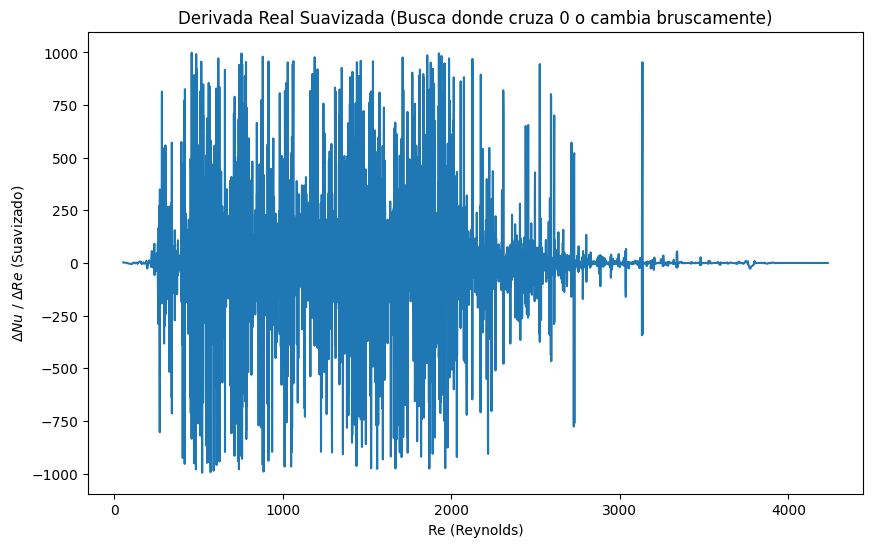

In [196]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import savgol_filter # <--- Importante

x_new0 = x_train.copy()
y_new0 = y_train.copy()

plt.figure(figsize=(10, 6))

# Datos del grupo actual
x_new = x_new0.reset_index(drop=True)
y_new = y_new0.reset_index(drop=True)

# 1. Ordenar por Re (CRUCIAL)
re_raw = x_new['Re'].to_numpy()
y_raw = y_new.to_numpy()

sort_idx = np.argsort(re_raw)
re_sorted = re_raw[sort_idx]
y_sorted = y_raw[sort_idx]

# Verificación de seguridad: evitar Re duplicados que causen división por cero
_, unique_indices = np.unique(re_sorted, return_index=True)
re_sorted = re_sorted[unique_indices]
y_sorted = y_sorted[unique_indices]

y_smooth = savgol_filter(y_sorted, window_length=11, polyorder=3)

# 3. Calcular derivada sobre la curva suavizada
dnu = np.diff(y_smooth) / np.diff(re_sorted)
re_axis = re_sorted[:-1] # Ajustar eje X

# Opcional: Suavizar también la derivada resultante para visualización "linda"
dnu_smooth = savgol_filter(dnu, window_length=9, polyorder=2)

# Graficar
mask_smooth = np.abs(dnu_smooth) < 1000
plt.plot(re_axis[mask_smooth], dnu_smooth[mask_smooth], label=f'Se group {k}')


plt.xlabel('Re (Reynolds)')
plt.ylabel(r'$\Delta Nu ~/~ \Delta Re$ (Suavizado)')
plt.title('Derivada Real Suavizada (Busca donde cruza 0 o cambia bruscamente)')
plt.show()

{'mae': 4.25, 'mape': 11.58, 'mae_std': 3.83, 'mape_std': 15.84}


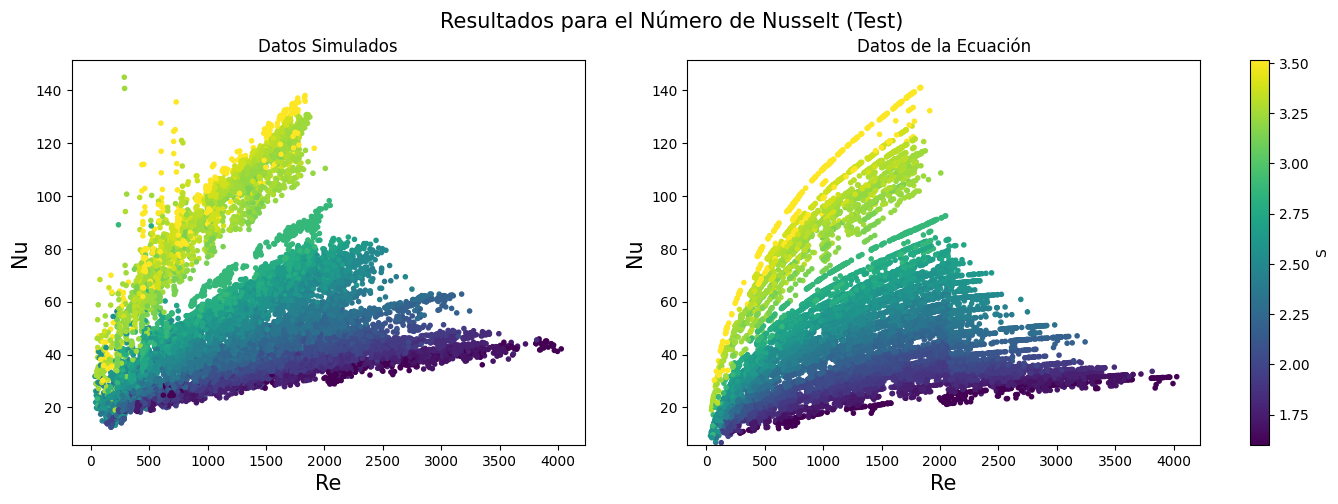

In [90]:
f = np.vectorize(lambda Re, Se, SoH, Pr: (
        Se ** 2.3 * Pr * Re ** 0.34 + 1.7 * SoH * Se ** 2.3 - 3 * Se ** 2.3 if Re < 2075 else
        Re ** 0.4 + Se ** 4.1 + 6.9 * SoH - 9.81
))

fig, ax = plt.subplots(1, 2, figsize=(16, 5))

x = x_test
y = y_test

sc0 = ax[0].scatter(x['Re'], y, marker='.', c=x['Se'])
ax[0].set_xlabel('Re', fontsize=15)
ax[0].set_ylabel('Nu', fontsize=15)
ax[0].set_title('Datos Simulados')

y_pred = f(x['Re'], x['Se'], x['SoH'], x['Pr'])
sc1 = ax[1].scatter(x['Re'], y_pred, marker='.', c=x['Se'])
ax[1].set_xlabel('Re', fontsize=15)
ax[1].set_ylabel('Nu', fontsize=15)
ax[1].set_ylim(ax[0].get_ylim())
ax[1].set_title('Datos de la Ecuación')

print(get_metrics(y, y_pred))
cbar = fig.colorbar(sc1, ax=ax, orientation='vertical', fraction=0.05, pad=0.04)
cbar.set_label('S')

fig.suptitle('Resultados para el Número de Nusselt (Test)', fontsize=15)
plt.show()

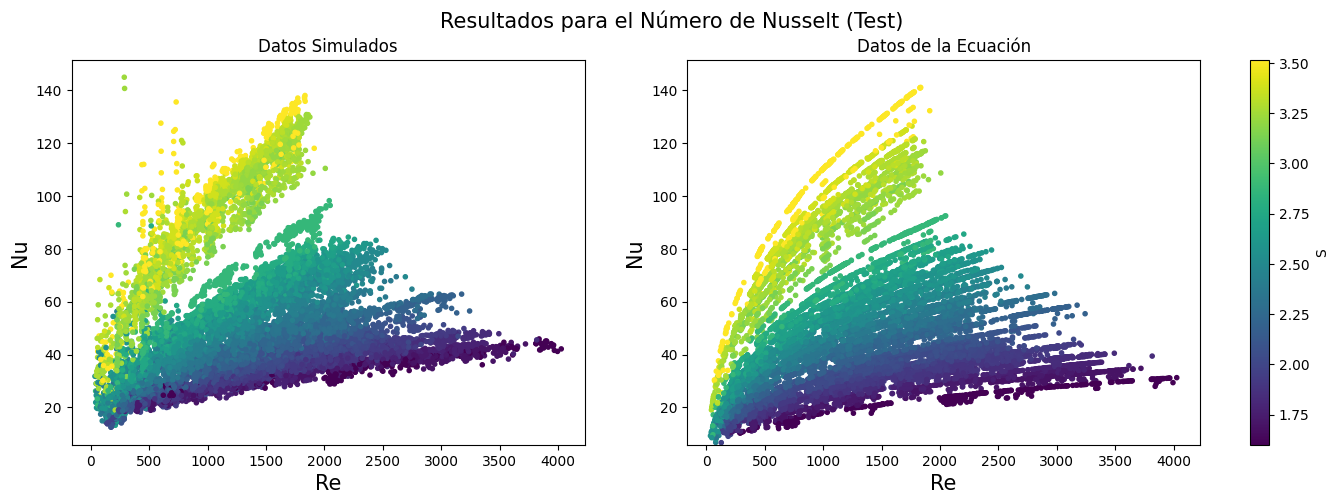

In [207]:
f = lambda Re, Se, SoH, Pr: (
        Se ** 2.3 * Pr * Re ** 0.34 + 1.7 * SoH * Se ** 2.3 - 3 * Se ** 2.3)

fig, ax = plt.subplots(1, 2, figsize=(16, 5))

x = x_test
y = y_test

sc0 = ax[0].scatter(x['Re'], y, marker='.', c=x['Se'])
ax[0].set_xlabel('Re', fontsize=15)
ax[0].set_ylabel('Nu', fontsize=15)
ax[0].set_title('Datos Simulados')

y_pred = f(x['Re'], x['Se'], x['SoH'], x['Pr'])
sc1 = ax[1].scatter(x['Re'], y_pred, marker='.', c=x['Se'])
ax[1].set_xlabel('Re', fontsize=15)
ax[1].set_ylabel('Nu', fontsize=15)
ax[1].set_ylim(ax[0].get_ylim())
ax[1].set_title('Datos de la Ecuación')
ax[1].set_xlim(ax[0].get_xlim())

cbar = fig.colorbar(sc1, ax=ax, orientation='vertical', fraction=0.05, pad=0.04)
cbar.set_label('S')

fig.suptitle('Resultados para el Número de Nusselt (Test)', fontsize=15)
plt.show()

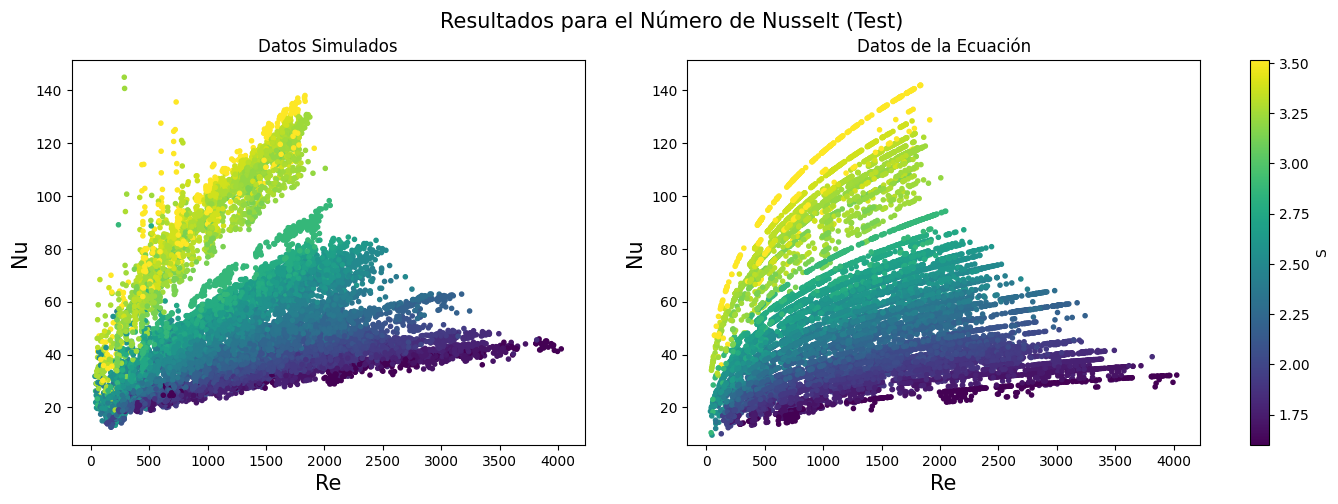

In [59]:
f = lambda Re, Se, SoH, Pr: (
        Se ** 2.2 * (Re ** 0.3 + SoH * 2.6 - 3.2))

fig, ax = plt.subplots(1, 2, figsize=(16, 5))

x = x_test
y = y_test

sc0 = ax[0].scatter(x['Re'], y, marker='.', c=x['Se'])
ax[0].set_xlabel('Re', fontsize=15)
ax[0].set_ylabel('Nu', fontsize=15)
ax[0].set_title('Datos Simulados')

y_pred = f(x['Re'], x['Se'], x['SoH'], x['Pr'])
sc1 = ax[1].scatter(x['Re'], y_pred, marker='.', c=x['Se'])
ax[1].set_xlabel('Re', fontsize=15)
ax[1].set_ylabel('Nu', fontsize=15)
ax[1].set_ylim(ax[0].get_ylim())
ax[1].set_title('Datos de la Ecuación')
ax[1].set_xlim(ax[0].get_xlim())

cbar = fig.colorbar(sc1, ax=ax, orientation='vertical', fraction=0.05, pad=0.04)
cbar.set_label('S')

fig.suptitle('Resultados para el Número de Nusselt (Test)', fontsize=15)
plt.show()

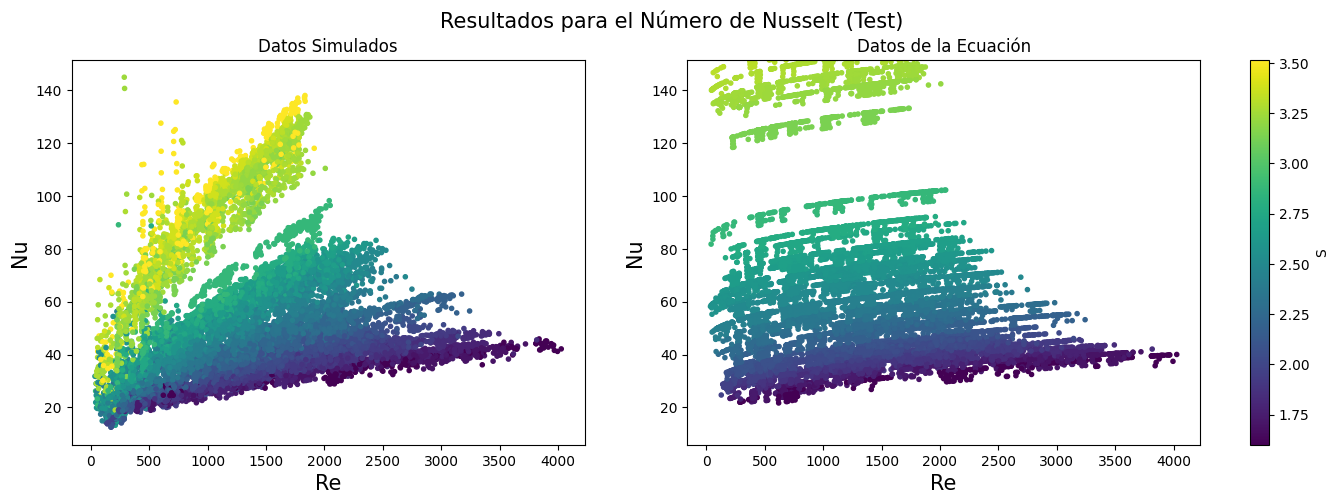

In [206]:
f = lambda Re, Se, SoH, Pr: (
         Re ** 0.4 + Se ** 4.1 + 6.9 * SoH - 1.4)

fig, ax = plt.subplots(1, 2, figsize=(16, 5))

x = x_test
y = y_test

sc0 = ax[0].scatter(x['Re'], y, marker='.', c=x['Se'])
ax[0].set_xlabel('Re', fontsize=15)
ax[0].set_ylabel('Nu', fontsize=15)
ax[0].set_title('Datos Simulados')

y_pred = f(x['Re'], x['Se'], x['SoH'], x['Pr'])
sc1 = ax[1].scatter(x['Re'], y_pred, marker='.', c=x['Se'])
ax[1].set_xlabel('Re', fontsize=15)
ax[1].set_ylabel('Nu', fontsize=15)
ax[1].set_ylim(ax[0].get_ylim())
ax[1].set_title('Datos de la Ecuación')
ax[1].set_xlim(ax[0].get_xlim())

cbar = fig.colorbar(sc1, ax=ax, orientation='vertical', fraction=0.05, pad=0.04)
cbar.set_label('S')

fig.suptitle('Resultados para el Número de Nusselt (Test)', fontsize=15)
plt.show()

{'mae': 3.53, 'mape': 8.08, 'mae_std': 3.56, 'mape_std': 10.54}


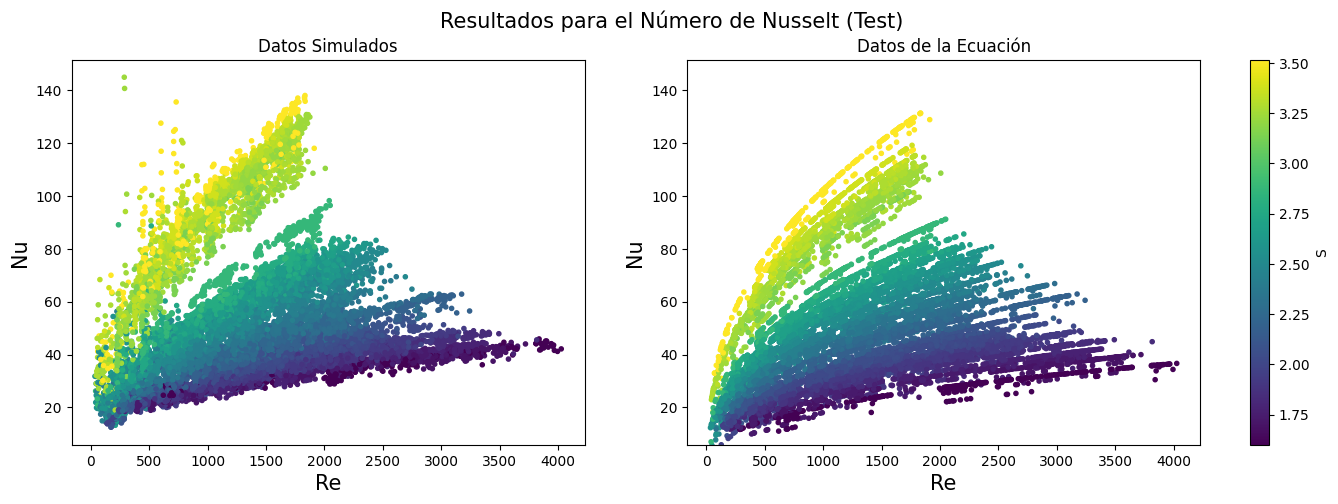

In [79]:
f = lambda Re, Se, SoH, Pr: (
         Se * (0.54 * Re ** 0.4 * Se - SoH ** (-1.88))
)

fig, ax = plt.subplots(1, 2, figsize=(16, 5))

x = x_test
y = y_test

sc0 = ax[0].scatter(x['Re'], y, marker='.', c=x['Se'])
ax[0].set_xlabel('Re', fontsize=15)
ax[0].set_ylabel('Nu', fontsize=15)
ax[0].set_title('Datos Simulados')

y_pred = f(x['Re'], x['Se'], x['SoH'], x['Pr'])
sc1 = ax[1].scatter(x['Re'], y_pred, marker='.', c=x['Se'])
ax[1].set_xlabel('Re', fontsize=15)
ax[1].set_ylabel('Nu', fontsize=15)
ax[1].set_ylim(ax[0].get_ylim())
ax[1].set_title('Datos de la Ecuación')
ax[1].set_xlim(ax[0].get_xlim())

cbar = fig.colorbar(sc1, ax=ax, orientation='vertical', fraction=0.05, pad=0.04)
cbar.set_label('S')

print(get_metrics(y, y_pred))
fig.suptitle('Resultados para el Número de Nusselt (Test)', fontsize=15)
plt.show()

In [49]:
nu_25[['Nu', 'Re', 'SoH', 'S', 'Pr']].corr().round(2)

,Nu,Re,SoH,S,Pr
Nu,1.00,0.19,0.10,0.77,0.15
Re,0.19,1.00,0.00,-0.32,0.25
SoH,0.10,0.00,1.00,-0.00,0.01
S,0.77,-0.32,-0.00,1.00,-0.03
Pr,0.15,0.25,0.01,-0.03,1.00


In [78]:
def get_metrics(y_pred, y_true):
    n = len(y_pred)
    error = np.abs(y_true - y_pred)
    mae = np.mean(error)
    mape = 100 * np.mean(np.abs((y_true - y_pred) / (y_true)))
    mae_std = np.std(np.abs(y_pred - y_true))
    mape_std = 100 * np.std(np.abs((y_pred - y_true) / y_true))

    return {'mae': float(np.round(mae, 2)),
            'mape': float(np.round(mape, 2)),
            'mae_std': float(np.round(mae_std, 2)),
            'mape_std': float(np.round(mape_std, 2))}